**Car Data Analysis and Visualization using Pandas**

**1.PROBLEM STATEMENTS**

1.To develop a Python program using Pandas and NumPy for efficient data handling and processing.

2.To create and manipulate data structures like Series and DataFrames dynamically.

3.To analyze a real-world dataset (cars dataset)
and extract statistical insights.

4.To identify relationships between variables using correlation and visualize the results for better understanding.

**2.IMPORTS**

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**3.RANGE SERIES**

In [64]:
def range_series(start=None, end=None):
    if start is None and end is None:
        start, end = 1, 10
    elif end is None:
        end = 10

    if start > end:
        raise ValueError("Start should be less than or equal to End")

    return pd.Series(range(start, end + 1))



**4.SUM OF NUMPY ARRAYS**

In [65]:
def sum_arrays(*arrays):
    if not arrays:
        raise ValueError("At least one array required")

    shape = arrays[0].shape

    for arr in arrays:
        if arr.shape != shape:
            raise ValueError("All arrays must have same dimensions")

    return np.sum(arrays, axis=0)


**5.CREATE DATAFRAME**

In [66]:
def create_dataframe(keys, values):
    if len(keys) != len(values):
        raise ValueError("Keys and values length mismatch")

    length = len(values[0])
    for v in values:
        if len(v) != length:
            raise ValueError("All value lists must be same length")

    return pd.DataFrame(dict(zip(keys, values)))


**5.CONCAT DATAFRAMES**

In [67]:
def concat_dataframes(df1, df2):
    return pd.concat([df1, df2], ignore_index=True)


**6.LOAD DATASET + FULL ANALYSIS**

In [68]:
def load_and_analyze(file_path):
    try:
        df = pd.read_csv(file_path)
    except FileNotFoundError:
        print("File not found!")
        return None

    print("\n📊 BASIC INFO")
    print(df.info())

    print("\n📈 STATISTICS")
    print(df.describe())

    print("\n❌ MISSING VALUES")
    print(df.isnull().sum())

    return df

**7.CORRELATION ANALYSIS**

In [69]:
def get_max_correlated_column(df, column_name):
    if column_name not in df.columns:
        raise ValueError("Column not found")

    corr = df.corr(numeric_only=True)

    if column_name not in corr:
        raise ValueError("Column must be numeric")

    return corr[column_name].drop(column_name).idxmax()

**8.VISUALIZATION**

In [70]:
def plot_histograms(df):
    df.hist()
    plt.suptitle("Feature Distributions")
    plt.show()


def plot_correlation_heatmap(df):
    corr = df.corr(numeric_only=True)

    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Heatmap")
    plt.show()


**9.MAIN EXECUTION**


===== RANGE SERIES =====
0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
dtype: int64
0     5
1     6
2     7
3     8
4     9
5    10
dtype: int64
0      5
1      6
2      7
3      8
4      9
5     10
6     11
7     12
8     13
9     14
10    15
dtype: int64

===== ARRAY SUM =====
[5 7 9]

===== DATAFRAME CREATION =====
  One Two
0   X   A
1   Y   B

===== CONCAT DATAFRAME =====
  One Two
0   X   A
1   Y   B
2   P   C
3   Q   D

===== LOAD DATASET =====

📊 BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mpg     10 non-null     int64  
 1   cyl     10 non-null     int64  
 2   disp    10 non-null     int64  
 3   hp      10 non-null     int64  
 4   drat    10 non-null     float64
 5   wt      10 non-null     float64
dtypes: float64(2), int64(4)
memory usage: 612.0 bytes
None

📈 STATISTICS
             mpg        

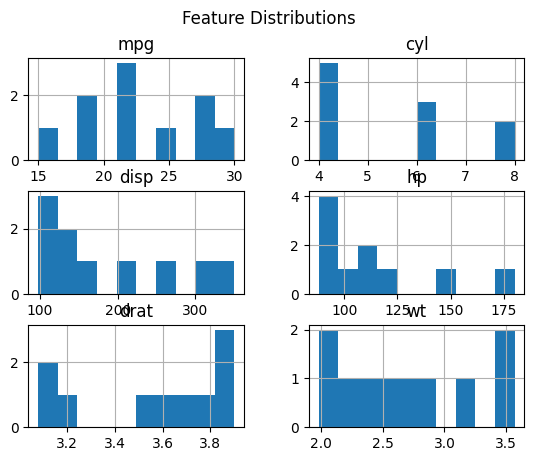

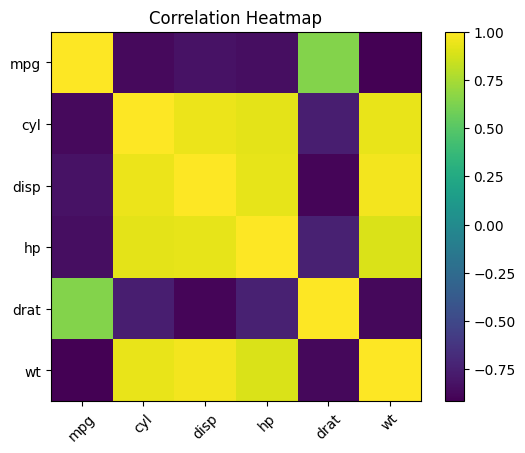

In [71]:
if __name__ == "__main__":

    print("\n===== RANGE SERIES =====")
    print(range_series())
    print(range_series(5))
    print(range_series(5, 15))

    print("\n===== ARRAY SUM =====")
    a = np.array([1, 2, 3])
    b = np.array([4, 5, 6])
    print(sum_arrays(a, b))

    print("\n===== DATAFRAME CREATION =====")
    df1 = create_dataframe(["One", "Two"], [["X", "Y"], ["A", "B"]])
    df2 = create_dataframe(["One", "Two"], [["P", "Q"], ["C", "D"]])
    print(df1)

    print("\n===== CONCAT DATAFRAME =====")
    combined = concat_dataframes(df1, df2)
    print(combined)

    print("\n===== LOAD DATASET =====")
    cars_df = load_and_analyze("cars.csv")

    if cars_df is not None:
        print("\n===== CORRELATION =====")
        print("Most correlated with mpg:",
              get_max_correlated_column(cars_df, 'mpg'))

        print("\n===== VISUALIZATION =====")
        plot_histograms(cars_df)
        plot_correlation_heatmap(cars_df)